1) Load Dataset (Iris)
Features shape: (150, 4)
Target shape: (150, 3)
--------------------------------------------------
2) Split Data into Train/Test
Train shape: (120, 4) (120, 3)
Test shape: (30, 4) (30, 3)
--------------------------------------------------
3) Build Artificial Neural Network


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115 (460.00 B)

 Trainable params: 115 (460.00 B)

 Non-trainable params: 0 (0.00 B)

None
--------------------------------------------------
4) Train the ANN
Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2527 - loss: 1.2239 - val_accuracy: 0.1667 - val_loss: 1.1813
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2561 - loss: 1.1185 - val_accuracy: 0.3333 - val_loss: 1.0673
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4548 - loss: 1.0231 - val_accuracy: 0.5667 - val_loss: 0.9604
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6388 - loss: 0.9379 - val_accuracy: 0.6667 - val_loss: 0.8669
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6140 - loss: 0.8626 - val_accuracy: 0.7000 - val_loss: 0.7822
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7120 - loss: 0.7693 - val_accuracy: 0.6667 - val_loss: 0.7008
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6973 - loss: 0.7238 - val_accuracy: 0.7000 - val_loss: 0.6331
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms

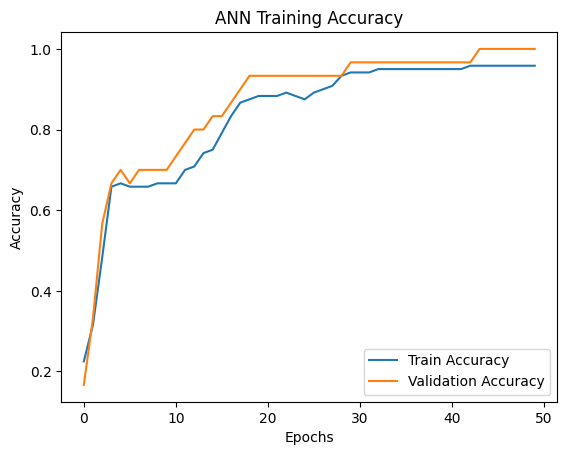

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

print("1) Load Dataset (Iris)")
iris = load_iris()
X = iris.data
y = pd.get_dummies(iris.target).values   # One-hot encoding for ANN

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("-" * 50)

print("2) Split Data into Train/Test")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("-" * 50)

print("3) Build Artificial Neural Network")
model = Sequential()
model.add(Dense(8, input_dim=4, activation="relu"))   # hidden layer 1
model.add(Dense(6, activation="relu"))                # hidden layer 2
model.add(Dense(3, activation="softmax"))             # output layer

model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

print(model.summary())

print("-" * 50)

print("4) Train the ANN")
history = model.fit(X_train, y_train, epochs=50, batch_size=5, verbose=1,
                    validation_data=(X_test, y_test))

print("-" * 50)

print("5) Evaluate the Model")
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", acc)

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Predicted Classes:", y_pred_classes[:10])
print("Actual Classes   :", y_true[:10])
print("Overall Accuracy :", accuracy_score(y_true, y_pred_classes))

print("-" * 50)

print("6) Visualization of Training Accuracy")
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("ANN Training Accuracy")
plt.show()
